# Assignment: Evaluating Data from a Form

A client has been testing a [small form](index.html) to gather some basic data about their client-base. They have brought their findings to you to validate the data they have gathered. You can open the `index.html` page in a browser to take a look at the form.

You have been provided a [dataset of csv records](../../data/form.csv) that contain entries from the form as well as some basic visualizations.The client pointed out that some of the visualizations look incorrect but they're unsure about how to resolve them. You can explore it in the [assignment notebook](assignment.ipynb).

## Instructions

Use the techniques in this lesson to make recommendations about the form so it captures accurate and consistent information. 

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Loading the dataset
path = "../../data/form.csv"
form_df = pd.read_csv(path)
form_df

,birth_month,state,pet
0,January,NaN,Cats
1,JAN,CA,Cats
2,Sept,Hawaii,Dog
3,january,AK,Dog
4,July,RI,Cats
5,September,California,Cats
6,April,CA,Dog
7,January,California,Cats
8,November,FL,Dog
9,December,Florida,Cats


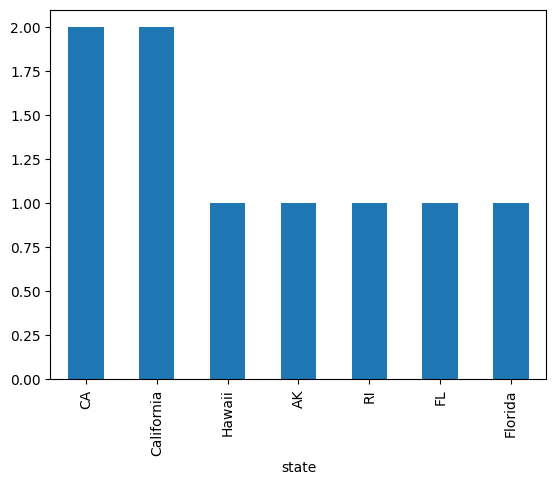

In [36]:
form_df["state"].value_counts().plot(kind="bar")
plt.show()

In the dataset there are inconsistent entries for the "state" column. Some entries are in uppercase, some are in lowercase, and some have leading or trailing whitespace.

Your task is to clean the "state" column so that all entries are in uppercase and have no leading or trailing whitespace.

For this task, let's first create a mapping dictionary.

In [37]:
map_states = {
    "ca": "CA",
    "california": "CA",
    "hawaii": "HI",
    "florida": "FL",
    "fl": "FL",
    "ak": "AK",
    "ri": "RI",
}

In [38]:
# Standardize categorical values from the "state" column
form_df["state"] = form_df["state"].str.strip().str.lower().map(map_states)

In [39]:
# Now check that the categories are standardized
form_df

,birth_month,state,pet
0,January,NaN,Cats
1,JAN,CA,Cats
2,Sept,HI,Dog
3,january,AK,Dog
4,July,RI,Cats
5,September,CA,Cats
6,April,CA,Dog
7,January,CA,Cats
8,November,FL,Dog
9,December,FL,Cats


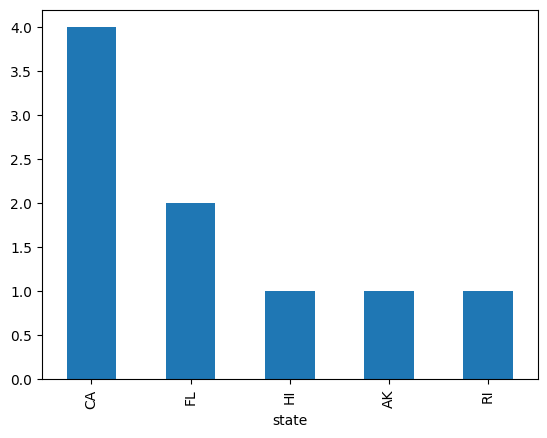

In [40]:
# And plot again the frequency table of the "state" column
form_df["state"].value_counts().plot(kind="bar")
plt.show()

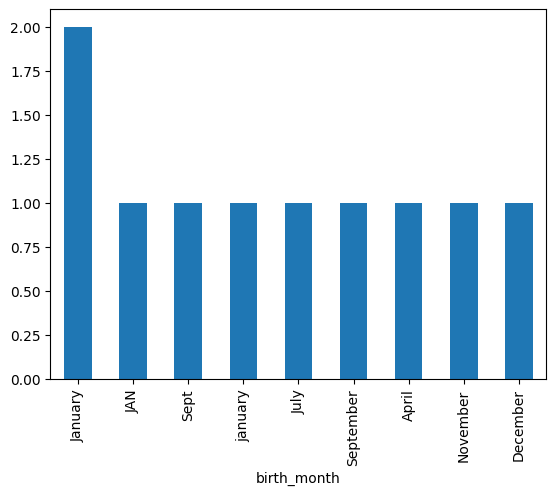

In [41]:
form_df["birth_month"].value_counts().plot(kind="bar")
plt.show()

The "birth_month" column contains the month of birth for each respondent. However, the entries are inconsistent, with some being full month names (e.g., "January") and others being abbreviated (e.g., "Jan"). Your task is to standardize the entries in the "birth_month" column so that all entries are in the same format (either full month names or abbreviations). You can create a mapping dictionary to achieve this.

In [42]:
month_mapping = {
    "jan": "January",
    "january": "January",
    "sept": "September",
    "september": "September",
    "july": "July",
    "april": "April",
    "november": "November",
    "december": "December",
}
form_df["birth_month"] = form_df["birth_month"].str.strip().str.lower().map(month_mapping)
form_df

,birth_month,state,pet
0,January,NaN,Cats
1,January,CA,Cats
2,September,HI,Dog
3,January,AK,Dog
4,July,RI,Cats
5,September,CA,Cats
6,April,CA,Dog
7,January,CA,Cats
8,November,FL,Dog
9,December,FL,Cats


<Axes: xlabel='birth_month'>

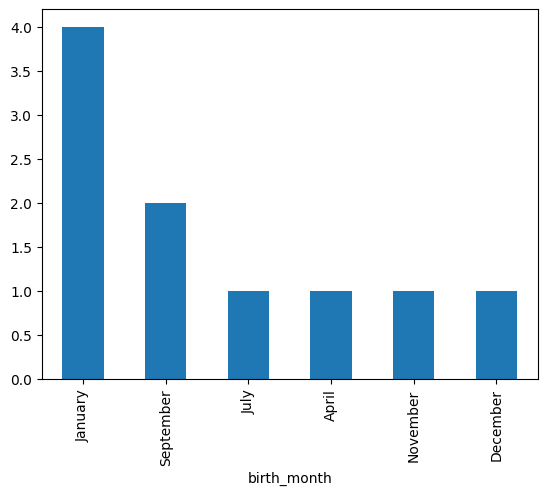

In [43]:
# Plot the frequency table of the "birth_month" column
form_df["birth_month"].value_counts().plot(kind="bar")